# UNET - F2 - AmaroXI - 1.2 M - Cleaned


## Libraries


In [1]:
new_name = '2_MSE'

In [2]:
import h5py
import numpy as np
from typing import Tuple
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import glob
import keras
import time

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data


In [4]:
def normalization_by_sample(x, p = False) -> np.ndarray:
    '''Normalize the array by taking a max and min value over a sample.

    Args:
        x: A NumPy array of shape (n, m), where n is the number of samples and m is the number of features.

    Returns:
        A NumPy array of the same shape (n, m), normalized by sample.
    '''

    mi = np.min(x, axis = 1, keepdims=True)
    ma = np.max(x, axis = 1, keepdims=True)
    if p:
        print(ma)
        print(mi)

    return (x - mi) / (ma - mi + 1e-6)


In [5]:
def load_data_normalization_sample_General(folder: str,
                                  size: list = None,
                                  names: list = None) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    '''
    Description:
        Loads train, test, and validation datasets from .h5 files in the given folder.
        Applies per-sample normalization to x datasets.

    Args:
        folder (str): Path to the folder containing the datasets in .h5 format.
        size (list): Number of samples to take from each dataset: [train, test, val].
        names (list): Dataset key names for x and y inside the .h5 files.

    Returns:
        x_train, y_train, x_test, y_test, x_val, y_val (np.ndarray)
    '''

    if size is None:
        size = [0, 0, 0]
    if names is None:
        names = ['x_total', 'y_total']

    _datapath_list = glob.glob(folder + '/*.h5')

    f1 = f2 = f3 = None

    for path in _datapath_list:
        if 'train' in path:
            f1 = h5py.File(path, 'r')
        elif 'test' in path:
            f2 = h5py.File(path, 'r')
        elif 'val' in path:
            f3 = h5py.File(path, 'r')

    if f1 is None:
        raise FileNotFoundError(f"No train .h5 file found in {folder}")
    if f2 is None:
        raise FileNotFoundError(f"No test .h5 file found in {folder}")
    if f3 is None:
        raise FileNotFoundError(f"No val .h5 file found in {folder}")

    if size[0] > 0:
        _xtrain = normalization_by_sample(f1[names[0]][:size[0]])
        _ytrain = f1[names[1]][:size[0]]
        _xtest, _ytest = normalization_by_sample(f2[names[0]][:size[1]]), f2[names[1]][:size[1]]
        _xval, _yval = normalization_by_sample(f3[names[0]][:size[2]]), f3[names[1]][:size[2]]
        return (_xtrain, _ytrain, _xtest, _ytest, _xval, _yval)
    else:
        _xtrain = normalization_by_sample(f1[names[0]][:])
        _ytrain = f1[names[1]][:]
        _xtest, _ytest = normalization_by_sample(f2[names[0]][:]), f2[names[1]][:]
        _xval, _yval = normalization_by_sample(f3[names[0]][:]), f3[names[1]][:]
        return (_xtrain, _ytrain, _xtest, _ytest, _xval, _yval)


In [6]:
data = load_data_normalization_sample_General(
    folder = '/content/drive/MyDrive/AzONet_New_145/notebooks/3_data_simulation/NewDataAzONetV2/Sets',
)


In [7]:
def show_dimensions(data: tuple) -> None:
    dims = [ dat.shape for dat in data]
    print('''
--------------------------------------------------
The dimensions of each dataset corresponds to:
--------------------------------------------------

Train:
    x: {}
    y: {}

Test:
    x: {}
    y: {}

Val:
    x: {}
    y: {}
    '''.format(dims[0], dims[1], dims[2], dims[3], dims[4], dims[5] ) )


In [8]:
show_dimensions(data)



--------------------------------------------------
The dimensions of each dataset corresponds to:
--------------------------------------------------

Train:
    x: (960000, 911, 1)
    y: (960000, 1)

Test:
    x: (120000, 911, 1)
    y: (120000, 1)

Val:
    x: (120000, 911, 1)
    y: (120000, 1)
    


In [9]:
def plot_xy(data: tuple) -> None:
    '''
    Description:
        This function plots a random element in the training data and, if exists, the corresponding y element.
    '''

    plt.figure(figsize = (12, 12))
    n = random.randint(0, data[0].shape[0])
    plt.plot(data[0][n], label = 'x element')
    plt.title('A random element in the x training dataset')
    plt.grid(True)
    plt.legend()
    plt.show()

    if len(data)>1:
        print('The corresponding y element ->', data[1][n])


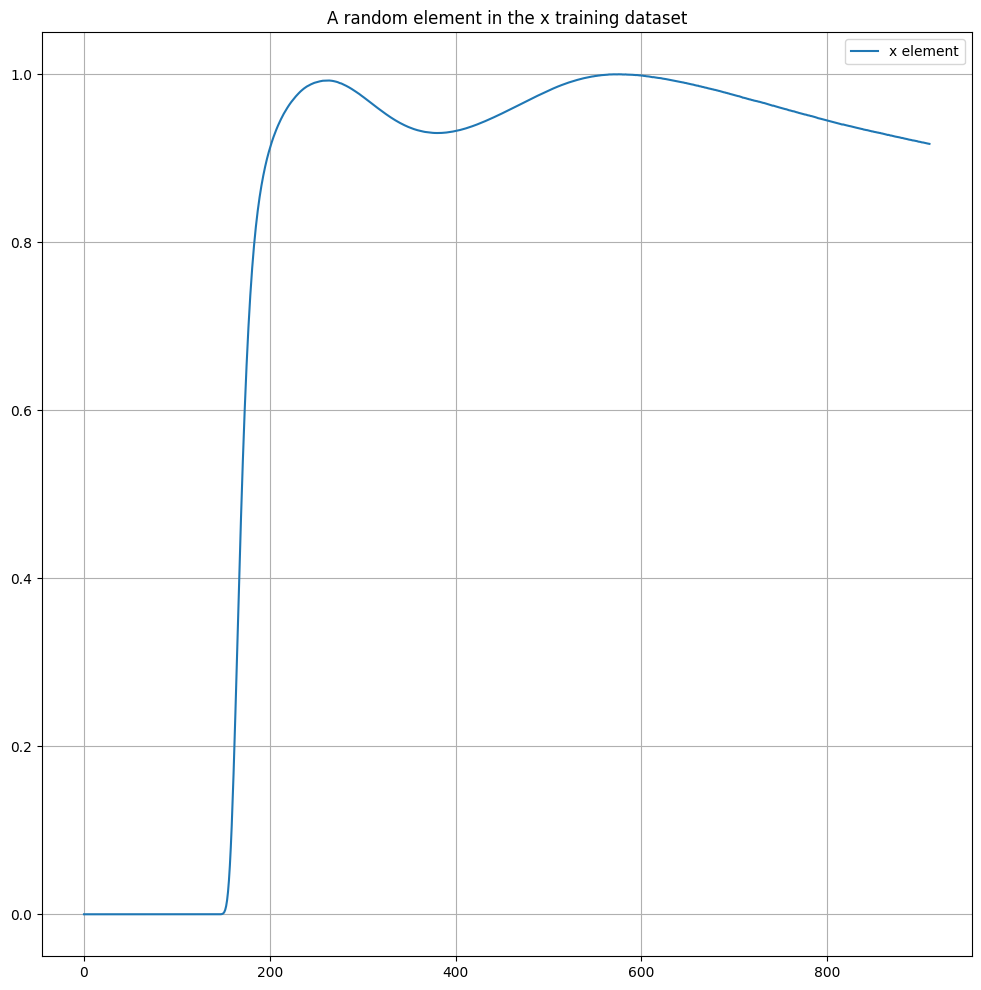

The corresponding y element -> [225.25673]


In [10]:
plot_xy(data)

In [11]:
x_train, y_train, x_test, y_test, x_val, y_val = data
del data


## GPU Allocation


In [12]:
! nvidia-smi


Mon Jun  8 21:11:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [13]:
def get_gpu(gpu_number: int = 0, p: bool = False) -> None:
    '''
    Description:
        This function gets, if available, a GPU.

    Args:
        gpu_number (int): Referring to the GPU to take.
        p (bool): Whether to print the total number of GPUs.
    '''
    gpus = tf.config.list_physical_devices('GPU')

    if gpus:
        tf.config.experimental.set_visible_devices(gpus[gpu_number], 'GPU')
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        if p:
            print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPU")


In [14]:
get_gpu(0)


## Paths


In [15]:
main_path = '/content/drive/MyDrive/AzONet_New_145/notebooks/5_training/{}'.format(new_name)
main_path

'/content/drive/MyDrive/AzONet_New_145/notebooks/5_training/2_MSE'

In [16]:
name = 'UNET-F145F2-New'
folder_path = main_path + '/models'
final_path = os.path.join(folder_path, name)

## Callbacks


In [17]:
def standard_callbacks(folder_name: str, patience: list, folder_path: str = '../Models',
                       monitor: str = 'val_metric_accuracy', flow_direction = 'max') -> tuple:
    '''
    Description:
        Returns the usual callbacks used during training: EarlyStopping, ReduceLR, Checkpoint, and CSVLogger.
        Creates the output folder if it does not exist.

    Args:
        folder_name (str): Folder name for saving model and logs.
        patience (list): Patience values for [EarlyStopping, ReduceLROnPlateau].
        folder_path (str): Base path where the folder will be created.
        monitor (str): Metric name to monitor. Defaults to 'val_metric_accuracy'.
        flow_direction (str): 'max' or 'min' depending on the metric.

    Returns:
        tuple: (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger)
    '''

    _path = folder_path + '/' + folder_name
    os.makedirs(_path, exist_ok = True)

    return (tf.keras.callbacks.EarlyStopping(monitor = monitor, patience = patience[0], restore_best_weights=True, mode = flow_direction),

            tf.keras.callbacks.ReduceLROnPlateau(monitor=monitor, factor=0.8,
                              patience= patience[1], min_lr=1e-6, mode=flow_direction),

           tf.keras.callbacks.ModelCheckpoint(
            filepath=  os.path.join(_path, '{}.keras'.format(folder_name) ),
            save_weights_only=False,
            monitor=monitor,
            mode= flow_direction,
            save_freq = 'epoch',
            save_best_only=True),

            keras.callbacks.CSVLogger( os.path.join(_path, 'training.log') )
           )


In [18]:
callbacks = standard_callbacks(folder_name= name,
                               folder_path= folder_path,
                               monitor='val_mape',
                               flow_direction= 'min',
                               patience= [1000, 1000],)  # EarlyStopping and ReduceLR are deactivated


## Seed


In [19]:
keras.utils.set_random_seed(13)


## UNET Model


In [20]:
def UNET_ConvDown(inputs: tf.Tensor, filters: int, power_of_two: int, kernel:int, act_func: str, pad_type:str,
                pool:int, stride:int, WIC:str, WRC, stride_conv: int = 1, pool_op = 'AP', pool_bool: bool = True) -> tf.Tensor:
    '''
        Applies a downsampling block consisting of two convolutional layers,
        batch normalization, activation functions, and optional pooling.

        Args:
            inputs (tf.Tensor): Input tensor of shape (batch_size, sequence_length, channels).
            filters (int): Base number of filters (multiplied by `2^power_of_two`).
            power_of_two (int): Exponent to scale filters as `filters * (2^power_of_two)`.
            kernel (int): Kernel size for convolutional layers.
            act_func (str): Activation function name (e.g., 'relu', 'sigmoid').
            pad_type (str): Padding type for pooling ('same' or 'valid').
            pool (int): Pooling window size.
            stride (int): Stride for pooling operations.
            WIC (str): Weight initializer for convolutional layers.
            WRC: Weight regularizer for convolutional layers.
            stride_conv (int, optional): Stride for convolutional layers. Defaults to 1.
            pool_op (str, optional): Pooling operation: 'AP' (AveragePooling), 'MP' (MaxPooling), or None. Defaults to 'AP'.
            pool_bool (bool, optional): If True, apply pooling and return both pooled and pre-pooling tensors. Defaults to True.

        Returns:
            tf.Tensor: If `pool_bool = False`, returns the activated output after convolutions.
            tuple[tf.Tensor, tf.Tensor]: If `pool_bool = True`, returns:
                - Pooled output tensor
                - Pre-pooling activation tensor (skip connection)

        Architecture:
            1. Conv1D → BatchNorm → Activation
            2. Conv1D → BatchNorm → Activation
            3. (Optional) Pooling (Average/Max) or identity pass
            '''

    n, f = power_of_two, filters

    Conv1 = keras.layers.Conv1D(
        filters = int( (2**n) *f),
        kernel_size = kernel,
        strides = stride_conv,
        padding = 'same',
        kernel_initializer = WIC,
        kernel_regularizer = WRC
    )(inputs)

    BN = keras.layers.BatchNormalization()(Conv1)
    Act = keras.layers.Activation(activation = act_func)(BN)

    Conv2 = keras.layers.Conv1D(
        filters = int( (2**n) *f),
        kernel_size = kernel,
        strides = stride_conv,
        padding = 'same',
        kernel_initializer = WIC,
        kernel_regularizer = WRC
    )(Act)

    BN = keras.layers.BatchNormalization()(Conv2)
    Act = keras.layers.Activation(activation = act_func)(BN)

    if pool_bool:

        if pool_op == 'AP':
            AP = keras.layers.AveragePooling1D(
                pool_size = pool,
                strides = stride,
                padding = pad_type
                )(Act)

        elif pool_op == 'MP':
            AP = keras.layers.MaxPooling1D(
            pool_size = pool,
            strides = stride,
            padding = pad_type
            )(Act)

        elif pool_op == None:
            AP = Act

        return AP, Act

    else:

        return Act


In [21]:
def UNET_ConvUp_US(inputs: tf.Tensor, block: tf.Tensor, filters: int, power_of_two: int, kernel:int, act_func: str, WIC:str, WRC:str,
                   stride_conv: int = 1) -> tf.Tensor:
    '''
    Performs upsampling and concatenation with skip connection followed by two convolutional layers.
    Handles dimension matching between encoder and decoder paths with automatic padding.

    Args:
        inputs (tf.Tensor): Input tensor from previous decoder layer.
        block (tf.Tensor): Skip connection tensor from corresponding encoder layer.
        filters (int): Base number of filters (multiplied by `2^power_of_two`).
        power_of_two (int): Exponent to scale filters as `filters * (2^power_of_two)`.
        kernel (int): Kernel size for convolutional layers.
        act_func (str): Activation function name (e.g., 'relu', 'sigmoid').
        WIC (str): Weight initializer for convolutional layers.
        WRC (str): Weight regularizer for convolutional layers.
        stride_conv (int, optional): Stride for convolutional layers. Defaults to 1.

    Returns:
        tf.Tensor: Processed tensor after upsampling, concatenation, and convolutions.

    Architecture:
        1. Calculate required upsampling size and padding
        2. Upsample input tensor
        3. Apply zero-padding if necessary for dimension matching
        4. Concatenate with skip connection
        5. Apply two Conv1D → BatchNorm → Activation blocks

    Dimension Handling:
        - Automatically calculates upsampling factor (n) and padding (m)
        - Handles both divisible and non-divisible dimension relationships
        - Uses zero-padding for fractional dimension adjustments
    '''

    _f, _n = filters, power_of_two

    # ---- UpSampling Section
    dim_in, dim_out = inputs.shape[1], block.shape[1]

    n = dim_out//dim_in
    r = dim_out%dim_in
    m = dim_out - (n*dim_in)

    if r == 0 :
        _Up = keras.layers.UpSampling1D(size = n)(inputs)

    elif r!=0:
        _Up = keras.layers.UpSampling1D(size = n)(inputs)
        _Up = keras.layers.ZeroPadding1D(padding = (0,m))(_Up)

    # ---- Concatenate Section
    _Up =keras.layers.Concatenate()([_Up, block])

    # ---- Process the block
    Conv1 = keras.layers.Conv1D(
        filters = int( (2**_n) *_f),
        kernel_size = kernel,
        strides = stride_conv,
        padding = 'same',
        kernel_initializer = WIC,
        kernel_regularizer = WRC
    )(_Up)

    BN = keras.layers.BatchNormalization()(Conv1)
    Act = keras.layers.Activation(activation = act_func)(BN)

    Conv2 = keras.layers.Conv1D(
        filters = int( (2**_n) *_f),
        kernel_size = kernel,
        strides = stride_conv,
        padding = 'same',
        kernel_initializer = WIC,
        kernel_regularizer = WRC
    )(Act)

    BN = keras.layers.BatchNormalization()(Conv2)
    Act = keras.layers.Activation(activation = act_func)(BN)

    return Act


In [22]:
def Up_Match_USConv(inputs: tf.Tensor, block: tf.Tensor):
    '''
    Description:
        This function upscales an input tensor using UpSampling1D to match the spatial dimensions
        of a reference block. The number of filters is preserved; a posterior convolutional layer
        should be applied if filter adjustment is needed.

    Args:
        inputs (tf.Tensor): Tensor to be UpSampled.
        block (tf.Tensor): Reference tensor whose spatial dimensions to match.
    '''
    dim_in, dim_out = inputs.shape[1], block.shape[1]
    n = dim_out//dim_in
    r = dim_out%dim_in
    m = dim_out - (n*dim_in)

    if r == 0 and (dim_in != dim_out):
        _Up = keras.layers.UpSampling1D(size = n)(inputs)

    elif r!=0:
        _Up = keras.layers.UpSampling1D(size = n)(inputs)
        _Up = keras.layers.ZeroPadding1D(padding = (0,m))(_Up)
    else:
        _Up = inputs

    return _Up


In [23]:
def G_UNET(inputs: tf.Tensor, layers:int, unet_kernel: list, WIC:str, WRC, pad_type:str, unet_act_func = 'leaky_relu',
           pool: int = 12, stride: int = 3, final_func_act: str = 'relu', stride_conv: int = 1, pool_op:str = 'AP',
           pool_bool: bool = True):
    '''
    Constructs a complete 1D U-Net generator with symmetric encoder-decoder architecture
    and skip connections between corresponding encoder and decoder blocks.

    Args:
        inputs (tf.Tensor): Input tensor of shape (batch_size, sequence_length, channels).
        layers (int): Base number of filters (scaled exponentially across layers).
        unet_kernel (list): List of kernel sizes for each encoder/decoder block.
        WIC (str): Weight initializer for all convolutional layers.
        WRC: Weight regularizer for all convolutional layers.
        pad_type (str): Padding type for pooling operations ('same' or 'valid').
        unet_act_func (str, optional): Activation function for intermediate layers. Defaults to 'leaky_relu'.
        pool (int, optional): Pooling window size. Defaults to 12.
        stride (int, optional): Stride for pooling operations. Defaults to 3.
        final_func_act (str, optional): Activation function for final output layer. Defaults to 'relu'.
        stride_conv (int, optional): Stride for convolutional layers. Defaults to 1.
        pool_op (str, optional): Pooling operation type: 'AP' (AveragePooling) or 'MP' (MaxPooling). Defaults to 'AP'.
        pool_bool (bool, optional): Whether to apply pooling in encoder blocks. Defaults to True.

    Returns:
        tf.Tensor: Output tensor with the same temporal dimensions as input, processed through U-Net.

    Architecture:
        Encoder Path:
          - Series of downsampling blocks (UNET_ConvDown)
          - Each block doubles the number of filters (2^power_of_two scaling)
          - Skip connections are stored for decoder path

        Bottleneck:
          - Highest abstraction level without pooling
          - Maximum filter count (2^(len(unet_kernel)-1) * layers)

        Decoder Path:
          - Series of upsampling blocks (UNET_ConvUp_US)
          - Each block halves the number of filters
          - Skip connections from encoder are concatenated
          - Uses learned upsampling with dimension matching

        Final Layer:
          - 1x1 convolution to produce output
          - Dimension matching with original input
    '''

    _blocks = []

    # Encoder Section ----------------- ConvDown
    Encoder, Concat = UNET_ConvDown(
        inputs= inputs,
        filters = layers,
        power_of_two = 0,
        kernel = unet_kernel[0],
        act_func = unet_act_func,
        pad_type = pad_type,
        pool = pool,
        stride = stride,
        WIC = WIC,
        WRC = WRC,
        stride_conv = stride_conv,
        pool_op = pool_op,
        pool_bool = pool_bool)

    _blocks.append(Concat)

    for i in range(1, len(unet_kernel) - 1 ):
        Encoder, Concat = UNET_ConvDown(
            inputs= Encoder,
            filters = layers,
            power_of_two = i,
            kernel = unet_kernel[i],
            act_func = unet_act_func,
            pad_type = pad_type,
            pool = pool,
            stride = stride,
            WIC = WIC,
            WRC = WRC,
            stride_conv = stride_conv,
            pool_op = pool_op,
            pool_bool = pool_bool)

        _blocks.append(Concat)

    # Bottleneck -------------------------------------
    Bottleneck = UNET_ConvDown(
            inputs= Encoder,
            filters = layers,
            power_of_two = len(unet_kernel)-1,
            kernel = unet_kernel[-1],
            act_func = unet_act_func,
            pad_type = pad_type,
            pool = pool,
            stride = stride,
            WIC = WIC,
            WRC = WRC,
            stride_conv = stride_conv,
            pool_op = pool_op,
            pool_bool = False)

    # Decoder Section ---------------- ConvUp_US
    Decoder = UNET_ConvUp_US(
        inputs = Bottleneck,
        block = _blocks[-1],
        filters= layers,
        power_of_two= len(unet_kernel)-2,
        kernel= unet_kernel[-2],
        act_func = unet_act_func,
        WIC=WIC,
        WRC=WRC,
        stride_conv= stride_conv)

    i = len(unet_kernel) -3
    for _block in reversed(_blocks[:-1]):
        Decoder = UNET_ConvUp_US(
            inputs = Decoder,
            block = _block,
            filters= layers,
            power_of_two= i,
            kernel= unet_kernel[i],
            act_func = unet_act_func,
            WIC=WIC,
            WRC=WRC,
            stride_conv = stride_conv)
        i -= 1

    Final_Stage = keras.layers.Conv1D(
        filters = 1,
        kernel_size = 1,
        kernel_initializer= WIC,
        activation = final_func_act)(
            Up_Match_USConv(Decoder, inputs)
        )

    return Final_Stage


In [24]:
def G_Dense(inputs: tf.Tensor, nodes: list, DP: int, n_final: int,
            act_func: str = 'leaky_relu', final_act_func: str = 'softmax',
            WI: str = 'he_normal', L1: float = 0.0, L2: float = 0.0,
            use_bias: bool = False) -> tf.Tensor:
    '''
    Description:
        Forward propagation through a series of dense layers, returning the desired number
        of output variables.

    Args:
        inputs (tf.Tensor): Input tensor.
        nodes (list): Number of nodes in each dense layer.
        DP (int): Dropout probability [0-100].
        n_final (int): Number of target variables.
        act_func (str): Activation function for intermediate dense layers.
        final_act_func (str): Activation function for the final layer.
        WI (str): Weight initializer.
        L1 (float): L1 regularization factor.
        L2 (float): L2 regularization factor.
        use_bias (bool): Whether to use bias in dense layers.

    Returns:
        tf.Tensor: Output of the last dense layer.
    '''
    WR = keras.regularizers.L1L2(l1 = L1, l2=L2)
    D = keras.layers.Dense(
        nodes[0],
        activation = act_func,
        kernel_initializer = WI,
        kernel_regularizer =  WR,
        use_bias = use_bias
        )(inputs)
    Drop = keras.layers.Dropout(DP/100)(D)
    BN = keras.layers.BatchNormalization()(Drop)

    for node in nodes[1:]:
        D = keras.layers.Dense(node,
                               activation = act_func,
                               kernel_initializer = WI,
                               kernel_regularizer =  WR,
                               use_bias = use_bias
                               )(BN)
        Drop = keras.layers.Dropout(DP/100)(D)
        BN = keras.layers.BatchNormalization()(Drop)

    return keras.layers.Dense(n_final,
                              activation = final_act_func,
                              kernel_initializer = WI,
                              use_bias = True
                              )(BN)


In [25]:
def _UNET():

    inputs = keras.layers.Input( (911,1) )

    _UNET = G_UNET(
        inputs = inputs,
        layers = 21,
        unet_kernel = [150, 50, 5],
        WIC = 'he_normal',
        WRC = keras.regularizers.L1L2(l1 = 1e-6 , l2= 1e-4),
        pad_type = 'valid',
        unet_act_func= 'leaky_relu',
        pool = 4,
        stride = 4,
        final_func_act= 'leaky_relu',
        stride_conv= 1,
        pool_op= 'AP',
        pool_bool= True,
    )

    _batch = keras.layers.BatchNormalization()(_UNET)
    _act = keras.layers.Activation(activation = 'leaky_relu')(_batch)

    _flatten = keras.layers.Flatten()(_act)

    _Dense = G_Dense(
        inputs = _flatten,
        nodes = [470, 340, 330],
        DP = 35,
        n_final = 1,
        act_func = 'leaky_relu',
        final_act_func= 'relu',
        WI = 'he_normal',
        L1 = 1e-6,
        L2 = 1e-5,
        use_bias= True
    )

    return keras.models.Model(inputs = inputs, outputs = _Dense)


In [26]:
modelo_UNET = _UNET()


In [27]:
modelo_UNET.compile(optimizer = keras.optimizers.Adam(),
                    loss = 'mean_squared_error',
                    metrics = [
                        'mape',
                        tf.keras.metrics.RootMeanSquaredError()
                    ])


In [28]:
def get_plot_model(model: keras.models.Model, folder_path:str ):
    '''
    Description:
        Plots the model architecture and saves it to the given path.

    Args:
        model (keras.models.Model): The model to plot.
        folder_path (str): Folder path to save the model diagram.
    '''

    keras.utils.plot_model(model,
                          to_file = folder_path + '/model.png',
                          show_shapes = True,
                          show_layer_names = True)


In [29]:
get_plot_model(modelo_UNET, folder_path= final_path)


## Training


In [30]:
def model_training(model: keras.models.Model, folder_path: str, batch_size: int,
                   num_epochs: int, x_train: np.ndarray, y_train: np.ndarray,
                   x_val: np.ndarray, y_val:np.ndarray,
                   callbacks: tuple):

    start_time = time.time()

    tensorboard_callback = keras.callbacks.TensorBoard(
    log_dir= os.path.join(folder_path, 'logs'), histogram_freq=1)

    model_trained = model.fit(x= x_train,
                        y= y_train,
                        epochs=num_epochs,
                        batch_size=batch_size,
                        validation_data = (x_val, y_val),
                        shuffle=True,
                        callbacks =[
                            tensorboard_callback,
                            callbacks[0],
                            callbacks[1],
                            callbacks[2],
                            callbacks[3]
                        ],
                        verbose=1 )

    end_time = time.time()
    minutes = (end_time - start_time)//60
    print("Time for training: {:10.4f}s".format(minutes))

    return model_trained


In [31]:
model_trained = model_training(modelo_UNET,
                               folder_path = final_path,
                               batch_size = 512,
                               num_epochs = 100,
                               x_train = x_train,
                               y_train = y_train,
                               x_val = x_val,
                               y_val = y_val,
                               callbacks = callbacks)


Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 135s 54ms/step - loss: 178780.4062 - mape: 48.6995 - root_mean_squared_error: 422.8241 - val_loss: 20029.0488 - val_mape: 20.6223 - val_root_mean_squared_error: 141.5230 - learning_rate: 0.0010
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 94s 50ms/step - loss: 2717.5942 - mape: 9.9548 - root_mean_squared_error: 52.1272 - val_loss: 862.3724 - val_mape: 6.5068 - val_root_mean_squared_error: 29.3594 - learning_rate: 0.0010
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 94s 50ms/step - loss: 1552.9486 - mape: 8.0584 - root_mean_squared_error: 39.4022 - val_loss: 456.6371 - val_mape: 4.0971 - val_root_mean_squared_error: 21.3590 - learning_rate: 0.0010
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 94s 50ms/step - loss: 1422.7029 - mape: 7.7384 - root_mean_squared_error: 37.7128 - val_loss: 3031.6567 - val_mape: 7.9311 - val_root_mean_squared_error: 55.0562 - learning_rate: 0.0010
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 94s 50ms/step - loss: 1374.6782 - m

## Save Model


In [32]:
modelo_UNET.save( os.path.join(final_path, 'model.keras') )


## Graphics


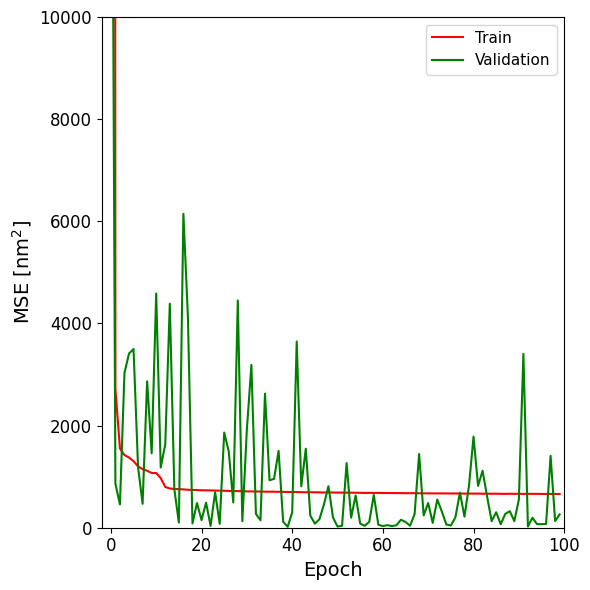

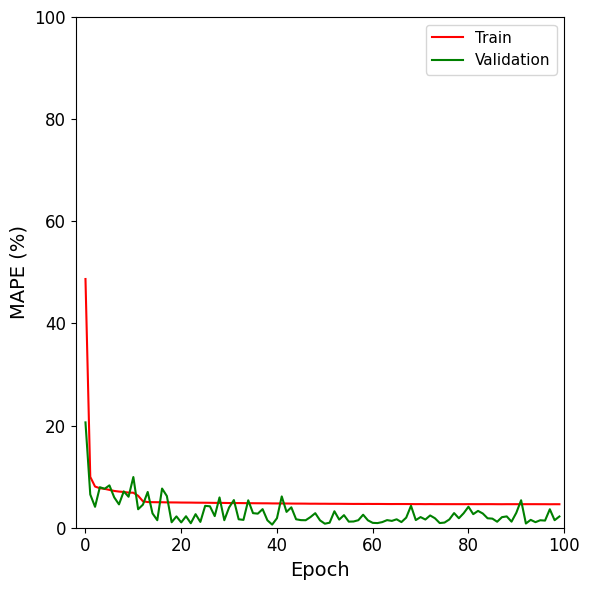

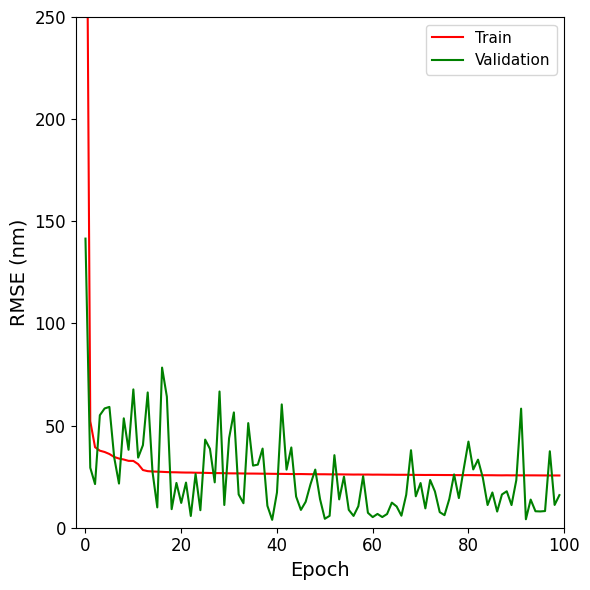

In [33]:

# Function definition with removed unused title argument and updated labels
def do_graphics(model_trained, folder_path: str, metric: str = 'mape'):
    '''
    Description:
        Generates MAE, MAPE, and RMSE plots over training epochs.

    Args:
        model_trained: Output of model.fit() with history attribute.
        folder_path (str): Folder path to save the plots.
        metric (str): Metric name for MAPE plot (e.g., 'mape').
    '''

    # --- 1. REMOVE SEABORN STYLING and use Matplotlib default style ---
    # The image has no grid and looks like standard matplotlib.
    # sns.set_style("whitegrid") # Removed
    # sns.set_context("notebook", font_scale=1.1) # Removed

    # Ensure a clean slate. Seaborn can leave persistent styling.
    plt.style.use('default')

    # --- 2. SET KEY FONT SIZES (to match image's readability) ---
    plt.rcParams['axes.labelsize'] = 14 # Axis labels (MAE, Epoch)
    plt.rcParams['xtick.labelsize'] = 12 # X-axis numbers (0, 20...)
    plt.rcParams['ytick.labelsize'] = 12 # Y-axis numbers (0, 50...)
    plt.rcParams['legend.fontsize'] = 11

    # --- 3. FIX EPOCHS RANGE (The image starts from Epoch 0) ---
    epochs = range(len(model_trained.history['loss'])) # e.g., 0 to 99

    # --- MAE plot ---
    # 4. Figure size. The image is more square. Let's use 6x6.
    plt.figure(figsize=(6, 6))

    # 5. LINE STYLES, COLORS, AND NO MARKERS
    # The image has a smooth red line for Train and a jagged green line for Validation.
    # Train: Red line
    plt.plot(epochs, model_trained.history['loss'],
             color='red', linewidth=1.5,
             label='Train')
    # Validation: Green line
    plt.plot(epochs, model_trained.history['val_loss'],
             color='green', linewidth=1.5,
             label='Validation')

    # --- 6. REMOVE GRID ---
    # plt.grid(True, linestyle='--', alpha=0.6, linewidth=0.5) # Removed

    # --- 7. UPDATE LABELS (Format from square to parentheses) ---
    # Removed explicit fontsizes here to rely on rcParams
    plt.ylabel(r'MSE [nm$^2$]')
    plt.xlabel('Epoch')

    # --- 8. ADD AXIS LIMITS (Matching image) ---
    plt.ylim(0, 10000 )
    plt.xlim(-2, 100) # Slightly wider to see '0' tick clearly

    # --- 9. LEGEND position (Matching image) ---
    plt.legend(loc='upper right', frameon=True) # frameon=True is standard

    # --- 10. REMOVE SEABORN DESPINE ---
    # The image has visible top and right axes (or at least the 'box' style).
    # sns.despine() # Removed

    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, 'mae.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # Apply same style to remaining plots consistently.

    # --- MAPE plot ---
    plt.figure(figsize=(6, 6))
    plt.plot(epochs, model_trained.history[metric],
             color='red', linewidth=1.5, label='Train')
    plt.plot(epochs, model_trained.history['val_'+metric],
             color='green', linewidth=1.5, label='Validation')
    plt.ylabel('MAPE (%)')
    plt.xlabel('Epoch')
    plt.ylim(0, 100) # Assuming realistic limit for MAPE
    plt.xlim(-2, 100)
    plt.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, 'mape.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # --- RMSE plot ---
    plt.figure(figsize=(6, 6))
    plt.plot(epochs, model_trained.history['root_mean_squared_error'],
             color='red', linewidth=1.5, label='Train')
    plt.plot(epochs, model_trained.history['val_root_mean_squared_error'],
             color='green', linewidth=1.5, label='Validation')
    plt.ylabel('RMSE (nm)')
    plt.xlabel('Epoch')
    # Use consistent range or adjust based on data
    plt.ylim(0, 250)
    plt.xlim(-2, 100)
    plt.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, 'rmse.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# Updated function call with removed parameters
do_graphics(model_trained,
            final_path,
            metric='mape'
            )

## Evaluate


In [34]:
score = modelo_UNET.evaluate(x = x_test, y = y_test)
score


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 18.6239 - mape: 0.6153 - root_mean_squared_error: 3.8908


[18.62394142150879, 0.6152895092964172, 3.8908472061157227]